<a href="https://colab.research.google.com/github/Faisalmalik01/deeplearning/blob/main/Image_classification_using_CNN_(CIFAR10_dataset).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [23]:
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

In [24]:
x_train.shape

(50000, 32, 32, 3)

In [25]:
x_test.shape

(10000, 32, 32, 3)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
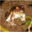

In [26]:
x_train[0]

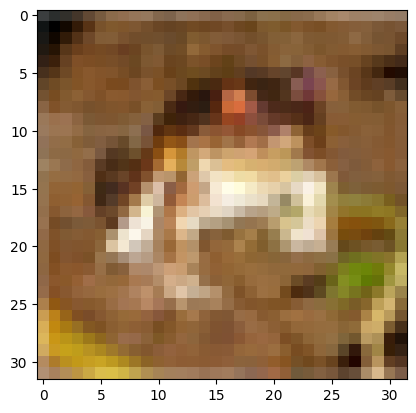

In [27]:
plt.imshow(x_train[0])

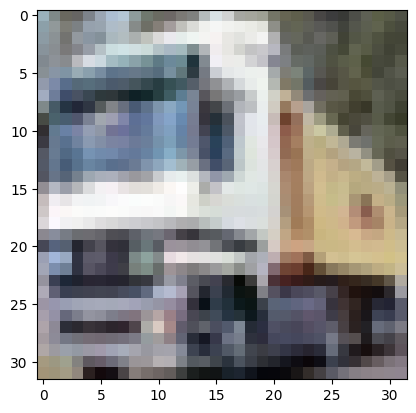

In [28]:
plt.imshow(x_train[1])

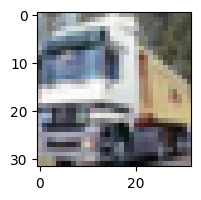

In [29]:
plt.figure(figsize = (15,2))
plt.imshow(x_train[1])

In [30]:
y_train.shape

(50000, 1)

In [31]:
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [32]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [33]:
classes = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [34]:
classes[9]

'truck'

In [35]:
def plot_sample(x, y, index):
  plt.figure(figsize=(15, 2))
  plt.imshow(x[index])
  plt.xlabel(classes[y[index]])
  plt.show()

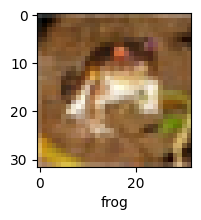

In [36]:
plot_sample(x_train, y_train, 0)

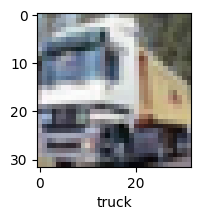

In [37]:
plot_sample(x_train, y_train, 1)

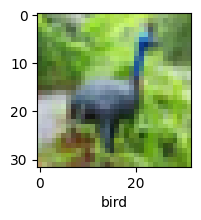

In [38]:
plot_sample(x_train, y_train, 6)

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]], dtype=uint8)
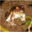

In [39]:
x_train[0]

In [40]:
x_train = x_train/255
x_test = x_test/255

In [42]:
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD',
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy'])

ann.fit(x_train, y_train, epochs=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 189s 121ms/step - accuracy: 0.3537 - loss: 1.8162
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 205s 123ms/step - accuracy: 0.4247 - loss: 1.6251
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 184s 111ms/step - accuracy: 0.4566 - loss: 1.5437
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 200s 128ms/step - accuracy: 0.4774 - loss: 1.4833
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 183s 116ms/step - accuracy: 0.4954 - loss: 1.4343


In [41]:
ann.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 34ms/step - accuracy: 0.4778 - loss: 1.4681


[1.4681202173233032, 0.47780001163482666]

In [43]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
y_pred = ann.predict(x_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.68      0.44      0.54      1000
           1       0.51      0.73      0.60      1000
           2       0.41      0.32      0.36      1000
           3       0.37      0.25      0.30      1000
           4       0.37      0.52      0.43      1000
           5       0.39      0.43      0.41      1000
           6       0.53      0.53      0.53      1000
           7       0.54      0.57      0.55      1000
           8       0.65      0.59      0.61      1000
           9       0.52      0.55      0.54      1000

    accuracy                           0.49     10000
   macro avg       0.50      0.49      0.49     10000
weighted avg       0.50      0.49      0.49     10000



now we are going to usee CNN to improve this mode. ANN didnt do well

In [45]:
cnn = models.Sequential([
    # cnn
    layers.Conv2D(filters=32, kernel_size=(3, 3),activation='relu',input_shape=(32, 32, 3) ),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # dense
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [47]:
cnn.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 51ms/step - accuracy: 0.4693 - loss: 1.4640
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 97s 62ms/step - accuracy: 0.6078 - loss: 1.1197
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 56ms/step - accuracy: 0.6590 - loss: 0.9828
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 52ms/step - accuracy: 0.6890 - loss: 0.8960
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.7134 - loss: 0.8263
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 62s 39ms/step - accuracy: 0.7354 - loss: 0.7668
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 60s 38ms/step - accuracy: 0.7499 - loss: 0.7156
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7657 - loss: 0.6691
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 61s 39ms/step - accuracy: 0.7802 - loss: 0.6284
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 38ms/step - accuracy: 0.7910 - loss: 0.5958


In [48]:
cnn.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6987 - loss: 0.9233


[0.9232725501060486, 0.6987000107765198]

Accuracy Clearly Improved

In [49]:
y_test[:5]

array([[3],
       [8],
       [8],
       [0],
       [6]], dtype=uint8)

In [50]:
y_test = y_test.reshape(-1,)
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

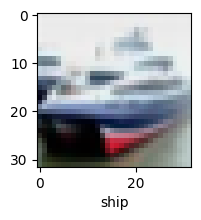

In [51]:
plot_sample(x_test, y_test, 1)

In [52]:
y_pred = cnn.predict(x_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


array([[8.0642840e-03, 5.2209233e-04, 1.0887339e-03, 8.8341957e-01,
        1.3109893e-04, 1.9520449e-02, 2.8288030e-04, 8.2316774e-06,
        8.6912580e-02, 5.0274222e-05],
       [1.8762681e-04, 8.5989843e-05, 5.8819025e-09, 1.2478666e-06,
        6.6228384e-11, 3.8029913e-09, 6.8542358e-09, 2.9825650e-10,
        9.9971771e-01, 7.3617916e-06],
       [5.1185697e-02, 9.8352335e-02, 1.3611607e-03, 3.3105396e-02,
        9.4395913e-03, 3.1738761e-03, 8.3785858e-03, 8.2064420e-03,
        2.9512879e-01, 4.9166816e-01],
       [7.1784091e-01, 2.7600492e-04, 5.7635251e-02, 2.9937160e-04,
        2.5912840e-02, 6.3586590e-06, 1.2818577e-03, 1.4413193e-04,
        1.9658050e-01, 2.2701761e-05],
       [2.8323029e-06, 4.8374146e-05, 2.2482665e-01, 1.1440956e-02,
        2.6238012e-01, 1.6674103e-03, 4.9961668e-01, 5.1370796e-07,
        1.5631360e-05, 7.9241306e-07]], dtype=float32)

In [55]:
np.argmax([5, 12, 1, 2])

np.int64(1)

In [56]:
np.argmax(y_pred[0])

np.int64(3)

In [57]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[np.int64(3), np.int64(8), np.int64(9), np.int64(0), np.int64(6)]

In [58]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

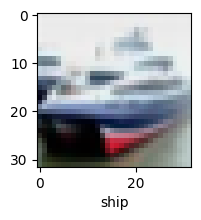

In [59]:
plot_sample(x_test, y_test, 1)

In [60]:
classes[y_classes[1]]

'ship'

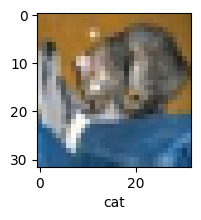

In [61]:
plot_sample(x_test, y_test, 0)

In [62]:
classes[y_classes[0]]

'cat'

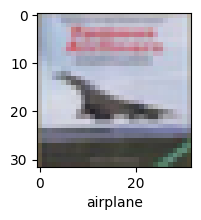

In [63]:
plot_sample(x_test, y_test, 3)

In [64]:
classes[y_classes[3]]

'airplane'

In [65]:
print("Classification Report: \n", classification_report(y_test, y_classes))

Classification Report: 
               precision    recall  f1-score   support

           0       0.74      0.73      0.74      1000
           1       0.88      0.73      0.80      1000
           2       0.56      0.62      0.59      1000
           3       0.54      0.48      0.51      1000
           4       0.62      0.69      0.65      1000
           5       0.62      0.63      0.63      1000
           6       0.71      0.83      0.77      1000
           7       0.78      0.69      0.73      1000
           8       0.80      0.81      0.80      1000
           9       0.78      0.77      0.78      1000

    accuracy                           0.70     10000
   macro avg       0.70      0.70      0.70     10000
weighted avg       0.70      0.70      0.70     10000



we are getting better score in CNN